# How much do you actually know from a Sharpe ratio?

**Docker image**: `ml4t`

## Purpose
A Sharpe ratio is an estimate computed from a sample, and like any estimate it has a distribution
around the quantity it is estimating. That distribution is much wider than most people expect: on
one year of daily data, the standard error of an annualized Sharpe is on the order of one, so a
strategy that reports a comfortably positive figure and a strategy with no edge at all produce
overlapping evidence.

This notebook builds the tools for saying how much a single strategy's Sharpe is worth: the
probability that its true value exceeds a benchmark, the amount of history that probability would
need to be convincing, and what changes when returns are skewed, fat-tailed or serially
dependent - all three of which real returns are.

It deliberately stops short of the harder problem. Everything here treats one strategy, chosen in
advance. A Sharpe that is the largest of many searched over needs a different correction, and
`12_dsr_validation` is where that happens.

## Learning objectives

- Put a confidence interval around a Sharpe ratio, and read it against the point estimate.
- Compute the probability that a strategy's true Sharpe exceeds a threshold, from the sample's
  own skewness and kurtosis rather than from a normal assumption.
- Work out how many observations a target Sharpe needs before it could be distinguished from
  zero, and use that number to decide whether an experiment is worth running.
- Annualize a Sharpe when returns are serially dependent, and judge how much to trust the
  correction on a sample of realistic length.
- Say why a large Sharpe picked from many candidates is not evidence, even when its
  single-strategy statistics look convincing.

## Book reference
Chapter 16, Section 16.7 (strategy-level overfitting control).

## Prerequisites

- Daily return series, annualized Sharpe ratios, and a working idea of a sampling distribution.

## The vocabulary, defined once

| | |
|---|---|
| **PSR**, probabilistic Sharpe ratio | The probability that a strategy's true Sharpe exceeds a stated benchmark, given the sample's length and shape |
| **MinTRL**, minimum track record length | The number of observations at which an observed Sharpe would clear a significance threshold |
| **Power planning** | The number of observations needed *before* collecting them, to have a stated chance of detecting a target Sharpe if it is real |
| **DSR**, deflated Sharpe ratio | The PSR corrected for having selected the largest of many candidates. `12_dsr_validation` |
| **Lo annualization** | Scaling a Sharpe from one frequency to another when returns are serially dependent, rather than by the square root of the frequency ratio |

## References

- López de Prado et al. (2025). "How to Use the Sharpe Ratio". ADIA Lab.
- Bailey & López de Prado (2014). "The Deflated Sharpe Ratio".
- Lo (2002). "The Statistics of Sharpe Ratios".

## Setup

In [1]:
"""Fixed-strategy Sharpe inference and track-record planning."""

# Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from ml4t.diagnostic.evaluation.stats import (
    compute_min_trl,
)
from ml4t.diagnostic.evaluation.stats import (
    deflated_sharpe_ratio as lib_dsr,
)
from scipy.stats import norm

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

In [2]:
# Production defaults - Papermill injects overrides after this cell
N_SIMULATIONS = 1000
SAMPLE_START = "2020"
SAMPLE_END = "2023"
DEMO_TRUE_SR = 0.5
DEMO_SAMPLE_DAYS = 252
DEMO_ANNUAL_VOL = 0.15
SEARCH_STRATEGIES = 30
SEARCH_REAL = 5
SEARCH_DAYS = 504
SEARCH_TRUE_SR = 0.8
SEED = 42

### What each setting decides

**Monte Carlo draws.** How many synthetic track records the sampling-distribution demonstration
generates. More draws sharpen the histogram and change nothing about the estimator.

**Sample window.** The years of SPY history every real-data example uses. Short enough to be a
realistic evaluation window and, as the notebook shows, far too short for the statistics people
routinely compute on it.

**Demonstration strategy.** A true annualized Sharpe, a sample length and an annual volatility.
Only the first two matter: the volatility cancels out of a Sharpe ratio and is there so the
simulated returns are on a recognizable scale.

**Search experiment.** How many strategies are tested, how many of them are real, how long each
track record is, and what Sharpe the real ones have. These decide how badly a naive reading of
the selected strategy's statistics fails, which is the point of section 6.

In [3]:
set_global_seeds(SEED)
rng = np.random.default_rng(SEED)
spy = load_etfs(symbols=["SPY"]).to_pandas()
spy = spy.set_index("timestamp").sort_index()
spy_returns = spy["close"].pct_change().dropna()
spy_sample = spy_returns.loc[SAMPLE_START:SAMPLE_END]
print(f"SPY history loaded: {spy_returns.index[0]:%Y-%m-%d} to {spy_returns.index[-1]:%Y-%m-%d}")
print(f"Sample used below:  {spy_sample.index[0]:%Y-%m-%d} to {spy_sample.index[-1]:%Y-%m-%d}")
print(f"Observations in the sample: {len(spy_sample):,}")

SPY history loaded: 2006-01-04 to 2025-12-31
Sample used below:  2020-01-02 to 2023-12-29
Observations in the sample: 1,006


## 1. What a Sharpe ratio's sampling distribution looks like

The Sharpe ratio is a **point estimate** with sampling uncertainty. For i.i.d.
normal returns at the native frequency:

$$\hat{SR} \sim \mathcal{N}\!\left(SR,\;\sqrt{\frac{1 + \tfrac{1}{2}SR^{2}}{T}}\right).$$

Real returns are non-normal *and* serially dependent, and both effects change
the standard error of $\widehat{SR}$. We separate the two adjustments:

1. **Non-normal i.i.d. (Mertens 2002).** With sample skewness $\gamma_3$ and
   kurtosis $\gamma_4$, the per-period variance is

   $$\text{Var}\bigl(\widehat{SR}\bigr) = \frac{1}{T}\!\left[1 - \gamma_3\,\widehat{SR} + \tfrac{\gamma_4 - 1}{4}\widehat{SR}^{\,2}\right].$$

   This is the asymptotic form. The implementation uses $T-1$ for the
   finite-sample Bessel correction in the PSR derivation.

2. **Autocorrelation-corrected annualization (Lo 2002, Eq. 17).** If we
   estimate $\widehat{SR}(1)$ at the native frequency, the annualized value
   is *not* $\sqrt{q}\,\widehat{SR}(1)$ when returns are autocorrelated. §4
   implements Lo's correction and shows the gap on real returns.

For the **combined** non-normal + AR(1) variance,
`ml4t.diagnostic.evaluation.stats.sharpe_inference.compute_sharpe_variance`
implements the López de Prado (2025) closed form; we benchmark against it
in §8.

In [4]:
def sharpe_ratio_variance(
    sr: float, n: int, skewness: float = 0.0, kurtosis: float = 3.0, periods_per_year: int = 252
) -> float:
    """Return Mertens' iid, non-normal variance for annualized Sharpe.

    Autocorrelation is excluded. Use ``lo_2002_annualized_sharpe`` for
    serial-correlation-aware annualization or the library variance routine for
    the combined non-normal and AR(1) correction.
    """
    if n < 2:
        raise ValueError("Need at least 2 observations for Sharpe-ratio inference.")

    # Convert annualized SR to per-period SR for the Mertens formula.
    sr_period = sr / np.sqrt(periods_per_year)
    excess_kurtosis = kurtosis - 3

    # Finite-sample PSR variance uses n - 1 (Bessel correction).
    variance_numerator = 1 - sr_period * skewness + 0.25 * sr_period**2 * (excess_kurtosis + 2)
    if variance_numerator <= 0:
        raise ValueError("The estimated Sharpe-ratio variance must be positive.")
    var_period = variance_numerator / (n - 1)

    # Scale back to annualized: Var(SR_annual) = q * Var(SR_period)
    var_annual = var_period * periods_per_year
    return max(var_annual, 1e-10)

### Annualizing a Sharpe when returns are serially dependent

Lo (2002, Eq. 17) shows that when returns are autocorrelated, the textbook
$\widehat{SR}(q) = \sqrt{q}\,\widehat{SR}(1)$ rule is wrong. With sample
autocorrelations $\hat\rho_k$, the annualized SR becomes

$$\widehat{SR}(q) = \widehat{SR}(1)\cdot
    \frac{q}{\sqrt{q + 2\sum_{k=1}^{q-1}(q-k)\hat\rho_k}}.$$

When all $\hat\rho_k = 0$ this reduces to $\sqrt{q}\,\widehat{SR}(1)$.
Positive autocorrelation inflates the denominator and pulls the annualized
Sharpe down; negative autocorrelation does the opposite. This is the
correct way to lift a daily Sharpe to an annual one when returns are not
i.i.d. In finite samples, estimating all $q-1$ autocorrelations is unstable,
so the implementation uses a Newey-West lag cutoff unless one is supplied.
We demonstrate it on real SPY returns in §4.

In [5]:
def _sample_autocorrelations(values: np.ndarray, max_lag: int) -> np.ndarray:
    """Return centered sample autocorrelations through ``max_lag``."""
    centered = values - values.mean()
    energy = float((centered**2).sum())
    return np.array(
        [float((centered[:-lag] * centered[lag:]).sum()) / energy for lag in range(1, max_lag + 1)]
    )

In [6]:
def lo_2002_annualized_sharpe(
    returns: pd.Series, periods_per_year: int = 252, max_lag: int | None = None
) -> dict:
    """Annualize Sharpe with Lo (2002, Eq. 17); default to a Newey-West lag."""
    r = pd.Series(returns).dropna().to_numpy()
    if r.size < 4:
        raise ValueError("Need at least 4 observations to estimate autocorrelations.")

    sr_period = float(r.mean() / r.std(ddof=1))
    q = int(periods_per_year)
    if q < 2:
        raise ValueError("periods_per_year must be at least 2.")
    if max_lag is None:
        max_lag = max(1, int(np.floor(4 * (r.size / 100) ** (2 / 9))))
    if max_lag < 1:
        raise ValueError("max_lag must be positive.")
    max_lag = min(max_lag, r.size - 2)

    rho = _sample_autocorrelations(r, max_lag)

    weights = np.array([q - k for k in range(1, max_lag + 1)], dtype=float)
    weighted_sum = float((weights * rho).sum())

    denom = q + 2.0 * weighted_sum
    if denom <= 0:
        raise ValueError("Lo annualization denominator is not positive for these returns.")
    multiplier = q / np.sqrt(denom)
    sr_annual_lo = sr_period * multiplier
    sr_annual_iid = sr_period * np.sqrt(q)

    return {
        "sr_period": sr_period,
        "sr_annual_iid": float(sr_annual_iid),
        "sr_annual_lo": float(sr_annual_lo),
        "annualization_multiplier_iid": float(np.sqrt(q)),
        "annualization_multiplier_lo": float(multiplier),
        "weighted_autocorrelation_sum": weighted_sum,
        "rho_lag1": float(rho[0]) if rho.size else 0.0,
        "max_lag": max_lag,
    }

### From variance to standard error

Convert the Sharpe-ratio variance estimate into a standard error.

In [7]:
def sharpe_ratio_se(
    sr: float, n: int, skewness: float = 0.0, kurtosis: float = 3.0, periods_per_year: int = 252
) -> float:
    """Standard error of annualized Sharpe ratio."""
    return np.sqrt(sharpe_ratio_variance(sr, n, skewness, kurtosis, periods_per_year))

The cheapest way to see how wide that distribution is: generate many track records from a
strategy whose true Sharpe is known, compute each one's Sharpe as a practitioner would, and look
at the spread. The theoretical standard error is drawn over the histogram, so the formula above
can be checked against the simulation rather than believed.

In [8]:
daily_vol = DEMO_ANNUAL_VOL / np.sqrt(252)
daily_mean = DEMO_TRUE_SR * DEMO_ANNUAL_VOL / 252
simulated_srs = np.array(
    [
        np.mean(draw) / np.std(draw, ddof=1) * np.sqrt(252)
        for draw in rng.normal(daily_mean, daily_vol, size=(N_SIMULATIONS, DEMO_SAMPLE_DAYS))
    ]
)
theoretical_se = sharpe_ratio_se(DEMO_TRUE_SR, DEMO_SAMPLE_DAYS)

print(f"True annualized Sharpe:  {DEMO_TRUE_SR}")
print(f"Observations per draw:   {DEMO_SAMPLE_DAYS}")
print(f"Mean of the estimates:   {np.mean(simulated_srs):.3f}")
print(f"Spread of the estimates: {np.std(simulated_srs, ddof=1):.3f}")
print(f"Standard error, formula: {theoretical_se:.3f}")

True annualized Sharpe:  0.5
Observations per draw:   252
Mean of the estimates:   0.499
Spread of the estimates: 1.000
Standard error, formula: 1.002


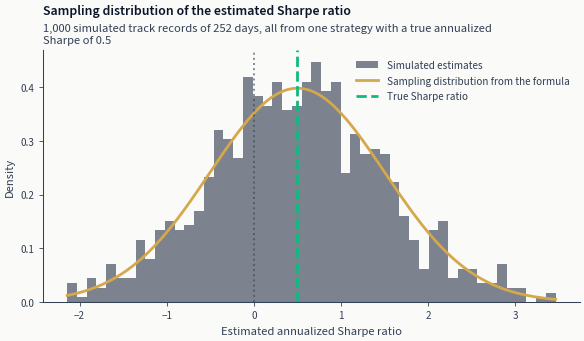

In [9]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.hist(
    simulated_srs,
    bins=50,
    density=True,
    alpha=0.55,
    color=COLORS["blue_light"],
    label="Simulated estimates",
)
grid = np.linspace(simulated_srs.min(), simulated_srs.max(), 300)
ax.plot(
    grid,
    norm.pdf(grid, loc=DEMO_TRUE_SR, scale=theoretical_se),
    color=COLORS["amber"],
    lw=2,
    label="Sampling distribution from the formula",
)
ax.axvline(DEMO_TRUE_SR, color=COLORS["positive"], linestyle="--", lw=2, label="True Sharpe ratio")
ax.axvline(0, color=COLORS["neutral"], linestyle=":", alpha=0.6)
ax.set_xlabel("Estimated annualized Sharpe ratio")
ax.set_ylabel("Density")
add_message_title(
    ax,
    "Sampling distribution of the estimated Sharpe ratio",
    subtitle=(
        f"{N_SIMULATIONS:,} simulated track records of {DEMO_SAMPLE_DAYS} days, "
        f"all from one strategy with a true annualized Sharpe of {DEMO_TRUE_SR}"
    ),
)
ax.legend()
_share_negative = float((simulated_srs < 0).mean())
show_with_alt(
    fig,
    (
        f"Histogram of {N_SIMULATIONS:,} simulated Sharpe estimates in grey with the "
        "analytical sampling distribution drawn over it as an amber curve, a dotted vertical "
        "line at zero and a dashed green line at the true Sharpe the draws were generated "
        "from. Every draw is the same length and the same underlying process, so the width of "
        "the histogram is estimation noise alone. Drawn with the formula on top to show what "
        "the closed form is claiming about that noise."
    ),
)

The estimates are centred on the truth, which is the only reassuring thing about them. Their
spread is roughly one Sharpe unit, so a quarter of these draws came out negative, from a strategy
that genuinely makes money. A practitioner handed any single one of these track records and
asked "does this work" cannot answer from the Sharpe alone.

## 2. The probability that the true Sharpe clears a benchmark

PSR answers: **What is the probability that the true SR exceeds a benchmark?**

$$PSR(\hat{SR}, SR^*) = \Phi\left(\frac{\hat{SR} - SR^*}{\hat{\sigma}(\hat{SR})}\right)$$

where $SR^*$ is the benchmark (often 0 or the risk-free rate).

In [10]:
def probabilistic_sharpe_ratio(
    observed_sr: float, benchmark_sr: float, n: int, skewness: float = 0.0, kurtosis: float = 3.0
) -> dict:
    """Return one-sided PSR inference against an annualized benchmark.

    The variance incorporates sample size, skewness, and Pearson kurtosis.
    """
    if not np.isfinite(observed_sr) or not np.isfinite(benchmark_sr):
        raise ValueError("Sharpe ratios must be finite.")
    se = sharpe_ratio_se(observed_sr, n, skewness, kurtosis)
    z_score = (observed_sr - benchmark_sr) / se
    psr = norm.cdf(z_score)

    # `sf` rather than `1 - psr`: subtracting a probability near one from one keeps only the
    # digits that survive the cancellation, and from z = 9 it returns exactly zero.
    upper_tail = float(norm.sf(z_score))
    one_sided_p_value = upper_tail
    two_sided_p_value = 2 * min(psr, upper_tail)

    return {
        "psr": psr,
        "z_score": z_score,
        "standard_error": se,
        "p_value": one_sided_p_value,
        "p_value_two_sided": two_sided_p_value,
        "ci_95_lower": observed_sr - 1.96 * se,
        "ci_95_upper": observed_sr + 1.96 * se,
    }

In [11]:
# Example: Evaluate a strategy
observed_sr = 1.2
n_obs = 252  # 1 year
benchmark = 0  # Test against zero

psr_result = probabilistic_sharpe_ratio(observed_sr, benchmark, n_obs)

print("=== Probabilistic Sharpe Ratio ===")
print(f"\nObserved SR: {observed_sr}")
print(f"Sample size: {n_obs} days")
print(f"Benchmark: {benchmark}")
print(f"\nPSR (P(true SR > {benchmark})): {psr_result['psr']:.1%}")
print(f"Z-score: {psr_result['z_score']:.2f}")
print(f"P-value (one-sided): {psr_result['p_value']:.4f}")
print(f"P-value (two-sided): {psr_result['p_value_two_sided']:.4f}")
print(f"95% CI: [{psr_result['ci_95_lower']:.2f}, {psr_result['ci_95_upper']:.2f}]")

=== Probabilistic Sharpe Ratio ===

Observed SR: 1.2
Sample size: 252 days
Benchmark: 0

PSR (P(true SR > 0)): 88.4%
Z-score: 1.20
P-value (one-sided): 0.1159
P-value (two-sided): 0.2317
95% CI: [-0.77, 3.17]


The same observed Sharpe means different things at different sample lengths. Reading down the
`psr` column below shows how much of the confidence in a strategy comes from the length of its
record rather than from its performance, and the confidence interval is the same statement in
units a reader can act on.

In [12]:
sample_sizes = [63, 126, 252, 504, 756, 1008]
observed_sr = 0.8

In [13]:
psr_rows = []
for n in sample_sizes:
    result = probabilistic_sharpe_ratio(observed_sr, 0, n)
    psr_rows.append(
        {
            "days": n,
            "years": n / 252,
            "standard_error": result["standard_error"],
            "psr": result["psr"],
            "ci_95_lower": result["ci_95_lower"],
            "ci_95_upper": result["ci_95_upper"],
        }
    )

pl.DataFrame(psr_rows)

days,years,standard_error,psr,ci_95_lower,ci_95_upper
i64,f64,f64,f64,f64,f64
63,0.25,2.017344,0.654154,-3.153995,4.753995
126,0.5,1.42076,0.713309,-1.98469,3.58469
252,1.0,1.002626,0.787537,-1.165147,2.765147
504,2.0,0.708259,0.870663,-0.588187,2.188187
756,3.0,0.578099,0.916797,-0.333074,1.933074
1008,4.0,0.500566,0.945,-0.181109,1.781109


## 3. How much history a Sharpe needs before it means anything

MinTRL answers: **How much data is needed to exceed a benchmark at a chosen confidence?**

Given an observed SR and significance level, canonical MinTRL computes the
minimum observations needed. A separate prospective planning calculation adds
a power target before data are collected.

Let $SR_p = SR_{ann}/\sqrt{q}$ denote Sharpe at the return series' native
frequency, where $q$ is periods per year. Canonical finite-sample MinTRL is

$$T_{min} = 1 +
\frac{z_{1-\alpha}^{2}\left[1-\gamma_3SR_p+
\frac{\gamma_4-1}{4}SR_p^2\right]}{(SR_p-SR_p^*)^2}.$$

For prospective planning with $SR_p^*=0$ and normal returns, the same
per-period Sharpe units give:

$$T_\text{plan} \approx
\frac{(z_{1-\alpha}+z_{1-\beta})^2\left(1 + \tfrac{1}{2}SR_p^2\right)}{SR_p^2}.$$

In [14]:
def _validate_mintrl_inputs(
    target_sr: float, benchmark_sr: float, alpha: float, power: float, periods_per_year: int
) -> None:
    """Reject invalid track-record planning inputs."""
    if target_sr <= benchmark_sr:
        raise ValueError("target_sr must exceed benchmark_sr.")
    if not 0 < alpha < 1:
        raise ValueError("alpha must lie strictly between 0 and 1.")
    if not 0 < power < 1:
        raise ValueError("power must lie strictly between 0 and 1.")
    if periods_per_year < 1:
        raise ValueError("periods_per_year must be positive.")

In [15]:
def minimum_track_record_length(
    target_sr: float,
    benchmark_sr: float = 0,
    alpha: float = 0.05,
    power: float = 0.80,
    skewness: float = 0.0,
    kurtosis: float = 3.0,
    periods_per_year: int = 252,
) -> dict:
    """Return canonical MinTRL and a prospective power-planning horizon."""
    _validate_mintrl_inputs(target_sr, benchmark_sr, alpha, power, periods_per_year)

    z_alpha = norm.ppf(1 - alpha)
    z_beta = norm.ppf(power)

    sr_period = target_sr / np.sqrt(periods_per_year)
    bench_period = benchmark_sr / np.sqrt(periods_per_year)
    excess_kurtosis = kurtosis - 3

    # Per-period variance numerator
    numer = 1 - sr_period * skewness + 0.25 * sr_period**2 * (excess_kurtosis + 2)
    sr_diff = sr_period - bench_period

    # Canonical finite-sample MinTRL includes the Bessel-correction offset.
    min_trl_sig = 1 + z_alpha**2 * numer / (sr_diff**2)

    # The chapter's prospective large-sample planning approximation adds the
    # desired-power quantile. It is a design target, not a second p-value test.
    planning_length = (z_alpha + z_beta) ** 2 * numer / (sr_diff**2)

    return {
        "min_trl_significance": int(np.ceil(min_trl_sig)),
        "planning_length_with_power": int(np.ceil(planning_length)),
        "target_sr": target_sr,
        "benchmark_sr": benchmark_sr,
        "alpha": alpha,
        "power": power,
        "z_alpha": z_alpha,
        "z_beta": z_beta,
    }

In [16]:
# MinTRL for different Sharpe ratios

Two numbers per target Sharpe. The first is the point at which an observed record of that
size would clear the significance threshold. The second is longer, because it also asks for a
stated chance of detecting the effect when it is real, and that is the one to use when deciding
whether an experiment is worth starting.

In [17]:
mintrl_rows = []
for sr in [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]:
    result = minimum_track_record_length(sr)
    mintrl_rows.append(
        {
            "target_sr": sr,
            "min_trl_significance_days": result["min_trl_significance"],
            "planning_length_days": result["planning_length_with_power"],
            "planning_length_years": result["planning_length_with_power"] / 252,
        }
    )
pl.DataFrame(mintrl_rows)

target_sr,min_trl_significance_days,planning_length_days,planning_length_years
f64,i64,i64,f64
0.3,7578,17315,68.710317
0.5,2730,6236,24.746032
0.8,1068,2438,9.674603
1.0,685,1562,6.198413
1.5,306,696,2.761905
2.0,173,393,1.559524


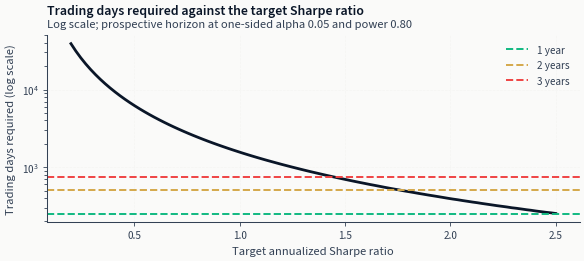


Planning result: a target annualized SR of 0.5 needs 24.7 years for 80% power.


In [18]:
# Visualize MinTRL
sr_range = np.linspace(0.2, 2.5, 100)
min_trl_values = [minimum_track_record_length(sr)["planning_length_with_power"] for sr in sr_range]

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.plot(sr_range, min_trl_values, color=COLORS["blue"], lw=2)
ax.axhline(252, color=COLORS["positive"], linestyle="--", label="1 year")
ax.axhline(504, color=COLORS["amber"], linestyle="--", label="2 years")
ax.axhline(756, color=COLORS["negative"], linestyle="--", label="3 years")

ax.set_xlabel("Target annualized Sharpe ratio")
ax.set_ylabel("Trading days required (log scale)")
add_message_title(
    ax,
    "Trading days required against the target Sharpe ratio",
    subtitle="Log scale; prospective horizon at one-sided alpha 0.05 and power 0.80",
)
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)


show_with_alt(
    fig,
    (
        "Line chart of the trading days required to distinguish a Sharpe ratio from zero "
        "against the target annualized Sharpe, on a logarithmic vertical axis, with dashed "
        "horizontal lines at one, two and three years of sessions. The axis is logarithmic "
        "because the requirement scales with the inverse square of the target; the reference "
        "lines convert the vertical axis into calendar terms."
    ),
)

sr_05 = minimum_track_record_length(0.5)
print(
    "\nPlanning result: a target annualized SR of 0.5 needs "
    f"{sr_05['planning_length_with_power'] / 252:.1f} years for 80% power."
)

## 4. What changes when returns are neither normal nor independent

Real returns have:
- **Negative skewness** (crash risk)
- **Excess kurtosis** (fat tails)
- **Autocorrelation** (momentum/mean reversion)

The skew/kurtosis effects enter the Sharpe **variance** through the Mertens
(2002) formula in §1 (`sharpe_ratio_variance`); we propagate them through
PSR in the table below. Autocorrelation enters separately, through Lo
(2002, Eq. 17) annualization - a wedge between the textbook
$\sqrt{q}\,\widehat{SR}(1)$ rule and the autocorrelation-corrected value.
We measure both on real SPY returns.

In [19]:
def compute_return_moments(returns: pd.Series) -> dict:
    """Compute mean, std, skewness, kurtosis of returns."""
    from scipy.stats import kurtosis, skew

    return {
        "mean": returns.mean(),
        "std": returns.std(),
        "skewness": skew(returns),
        "kurtosis": kurtosis(returns, fisher=False),  # Regular kurtosis (3 for normal)
        "excess_kurtosis": kurtosis(returns),  # Excess kurtosis (0 for normal)
        "sharpe": returns.mean() / returns.std() * np.sqrt(252),
    }

In [20]:
# Analyze real return moments
moments = compute_return_moments(spy_sample)

print(f"SPY daily return moments, {SAMPLE_START} to {SAMPLE_END}")
for key, value in moments.items():
    print(f"{key:20}: {value:.4f}")

SPY daily return moments, 2020 to 2023
mean                : 0.0006
std                 : 0.0142
skewness            : -0.5100
kurtosis            : 13.2978
excess_kurtosis     : 10.2978
sharpe              : 0.6151


In [21]:
# Compare PSR with and without non-normality adjustment
observed_sr = moments["sharpe"]
n = len(spy_sample)

# Normal assumption
psr_normal = probabilistic_sharpe_ratio(observed_sr, 0, n, skewness=0, kurtosis=3)

# Adjusted for actual moments
psr_adjusted = probabilistic_sharpe_ratio(
    observed_sr, 0, n, skewness=moments["skewness"], kurtosis=moments["kurtosis"]
)

**PSR comparison: normal vs skew/kurtosis-adjusted** (observed SR / sample
size shown above). Note: this comparison adjusts for *non-normality* only;
the autocorrelation correction enters separately via Lo (2002)
annualization, demonstrated immediately below.

In [22]:
pl.DataFrame(
    {
        "metric": [
            "Standard error",
            "PSR",
            "One-sided p-value",
            "95% CI lower",
            "95% CI upper",
        ],
        "normal": [
            psr_normal["standard_error"],
            psr_normal["psr"],
            psr_normal["p_value"],
            psr_normal["ci_95_lower"],
            psr_normal["ci_95_upper"],
        ],
        "adjusted": [
            psr_adjusted["standard_error"],
            psr_adjusted["psr"],
            psr_adjusted["p_value"],
            psr_adjusted["ci_95_lower"],
            psr_adjusted["ci_95_upper"],
        ],
    }
)

metric,normal,adjusted
str,f64,f64
"""Standard error""",0.500934,0.506813
"""PSR""",0.890274,0.887577
"""One-sided p-value""",0.109726,0.112423
"""95% CI lower""",-0.366689,-0.378213
"""95% CI upper""",1.596971,1.608494


### The correction on real SPY returns

Apply `lo_2002_annualized_sharpe` to the SPY 2020-2023 series. The textbook
IID rule reports $\sqrt{252}\,\widehat{SR}(1)$; Lo's correction adds the
weighted-autocorrelation term in the denominator. The difference between
the two annualizations is the autocorrelation wedge the chapter §16.7
narrative warns about.

In [23]:
lo_result = lo_2002_annualized_sharpe(spy_sample, periods_per_year=252)
pl.DataFrame(
    {
        "quantity": [
            "Native (daily) SR",
            "Annualized SR - IID (sqrt(q) rule)",
            "Annualized SR - Lo (2002, Eq. 17)",
            "Annualization multiplier - IID",
            "Annualization multiplier - Lo",
            f"Sum_{{k=1}}^{{{lo_result['max_lag']}}}(q-k) * rho_k",
            "rho at lag 1",
        ],
        "value": [
            lo_result["sr_period"],
            lo_result["sr_annual_iid"],
            lo_result["sr_annual_lo"],
            lo_result["annualization_multiplier_iid"],
            lo_result["annualization_multiplier_lo"],
            lo_result["weighted_autocorrelation_sum"],
            lo_result["rho_lag1"],
        ],
    }
)

quantity,value
str,f64
"""Native (daily) SR""",0.03875
"""Annualized SR - IID (sqrt(q) r…",0.615141
"""Annualized SR - Lo (2002, Eq. …",0.8396
"""Annualization multiplier - IID""",15.874508
"""Annualization multiplier - Lo""",21.666965
"""Sum_{k=1}^{6}(q-k) * rho_k""",-58.364464
"""rho at lag 1""",-0.172794


The multiplier need not equal $\sqrt{252}$, and here it is not close. Positive weighted
autocorrelation pulls the annualized Sharpe down, because variance accumulates faster than
proportionally with horizon; negative autocorrelation, which is what this sample has, pushes it
up.

Before taking the corrected number, look at how it is built. Each $\hat\rho_k$ carries a
standard error of roughly $1/\sqrt{T}$, about three points on a thousand observations, and the
formula multiplies each one by a weight close to $q$ - here around 250. A sampling error of three
points in a single autocorrelation therefore moves the denominator by about fifteen, which is six
percent of $q$ before anything real has happened. The correction is right in principle and noisy
in practice at this lag structure.

The cheapest way to see how noisy is to compute it on each year separately.

In [24]:
lo_by_year = pl.DataFrame(
    [
        {
            "year": year,
            "days": int(len(spy_sample.loc[year])),
            "sr_annual_iid": lo_2002_annualized_sharpe(spy_sample.loc[year])["sr_annual_iid"],
            "sr_annual_lo": lo_2002_annualized_sharpe(spy_sample.loc[year])["sr_annual_lo"],
            "multiplier_lo": lo_2002_annualized_sharpe(spy_sample.loc[year])[
                "annualization_multiplier_lo"
            ],
            "rho_lag1": lo_2002_annualized_sharpe(spy_sample.loc[year])["rho_lag1"],
        }
        for year in [str(y) for y in range(int(SAMPLE_START), int(SAMPLE_END) + 1)]
    ]
)
lo_by_year

year,days,sr_annual_iid,sr_annual_lo,multiplier_lo,rho_lag1
str,i64,f64,f64,f64,f64
"""2020""",253,0.670112,0.868707,20.57908,-0.318748
"""2021""",252,2.009994,2.719045,21.474441,-0.067054
"""2022""",251,-0.709588,-0.78891,17.64905,0.007156
"""2023""",250,1.858299,1.907388,16.293846,0.032207


Across four years of the same instrument the multiplier ranges over about five units, which is
comparable to the entire correction it delivers on the pooled sample. The lag-1 autocorrelation
behind it changes sign between years. That is what an estimator dominated by sampling error looks
like.

It does not make the correction wrong, and ignoring serial dependence is not the safer choice -
the uncorrected rule is simply a different estimator, one that assumes the autocorrelations are
exactly zero. What it means is that the corrected Sharpe deserves the same treatment as the
uncorrected one: a point estimate with a wide interval around it, which is the subject of this
whole notebook.

### What five years of a Sharpe of one is worth

A concrete reference point, because "the interval is wide" is easier to dismiss than a number.
A strategy reports an annualized Sharpe of one on five years of daily data - a track record most
allocators would call substantial. The interval below is computed twice: once assuming returns
are normal, and once with the skewness and kurtosis measured on real SPY returns above.

In [25]:
five_year_days = 252 * 5
five_year_normal = probabilistic_sharpe_ratio(1.0, 0, five_year_days, skewness=0.0, kurtosis=3.0)
five_year_actual = probabilistic_sharpe_ratio(
    1.0, 0, five_year_days, skewness=moments["skewness"], kurtosis=moments["kurtosis"]
)
pl.DataFrame(
    {
        "assumption": ["Normal returns", "Measured skew and kurtosis"],
        "standard_error": [five_year_normal["standard_error"], five_year_actual["standard_error"]],
        "ci_95_lower": [five_year_normal["ci_95_lower"], five_year_actual["ci_95_lower"]],
        "ci_95_upper": [five_year_normal["ci_95_upper"], five_year_actual["ci_95_upper"]],
        "ci_width": [
            five_year_normal["ci_95_upper"] - five_year_normal["ci_95_lower"],
            five_year_actual["ci_95_upper"] - five_year_actual["ci_95_lower"],
        ],
    }
)

assumption,standard_error,ci_95_lower,ci_95_upper,ci_width
str,f64,f64,f64,f64
"""Normal returns""",0.447835,0.122244,1.877756,1.755512
"""Measured skew and kurtosis""",0.4572,0.103888,1.896112,1.792224


## 5. Putting it together for one strategy

The significance statement below rests on the Mertens correction for skewness and kurtosis, and
treats returns as serially independent. The Lo-adjusted Sharpe is reported alongside it as a
diagnostic and deliberately does not feed the significance calculation: as the previous section
showed, at this sample length the corrected annualization is too unstable to carry a threshold.

In [26]:
def _sharpe_sample_statistics(returns: pd.Series) -> tuple[pd.Series, int, float, float, float]:
    """Return cleaned observations and their Sharpe-distribution inputs."""
    from scipy.stats import kurtosis, skew

    clean = pd.Series(returns).dropna()
    if len(clean) < 4:
        raise ValueError("Need at least 4 finite returns for complete Sharpe inference.")
    std_ret = clean.std(ddof=1)
    if std_ret <= 0:
        raise ValueError("Return standard deviation must be positive.")
    observed_sr = clean.mean() / std_ret * np.sqrt(252)
    return clean, len(clean), observed_sr, skew(clean), kurtosis(clean, fisher=False)

In [27]:
def _observed_mintrl(
    observed_sr: float,
    benchmark_sr: float,
    alpha: float,
    skewness: float,
    kurtosis: float,
) -> dict:
    """Return canonical MinTRL or infinities below the benchmark."""
    if observed_sr <= benchmark_sr:
        return {
            "min_trl_significance": np.inf,
            "planning_length_with_power": np.inf,
        }
    return minimum_track_record_length(
        observed_sr,
        benchmark_sr,
        alpha=alpha,
        power=0.80,
        skewness=skewness,
        kurtosis=kurtosis,
    )

In [28]:
def complete_sharpe_inference(
    returns: pd.Series, benchmark_sr: float = 0, alpha: float = 0.05
) -> dict:
    """Combine fixed-strategy PSR, MinTRL, and Lo annualization.

    Selection adjustment remains the separate DSR layer in Notebook 12.
    """
    clean, n, observed_sr, skew_val, kurt_val = _sharpe_sample_statistics(returns)
    psr_result = probabilistic_sharpe_ratio(observed_sr, benchmark_sr, n, skew_val, kurt_val)
    mintrl_result = _observed_mintrl(observed_sr, benchmark_sr, alpha, skew_val, kurt_val)
    lo_block = lo_2002_annualized_sharpe(clean, periods_per_year=252)
    is_significant_psr = psr_result["p_value"] < alpha
    has_sufficient_data = n >= mintrl_result.get("min_trl_significance", np.inf)
    iid_mertens_inference_status = "SIGNIFICANT" if is_significant_psr else "NOT SIGNIFICANT"

    return {
        "n_observations": n,
        "observed_sr_iid": observed_sr,
        "observed_sr_lo": lo_block["sr_annual_lo"],
        "annualization_multiplier_lo": lo_block["annualization_multiplier_lo"],
        "weighted_autocorrelation_sum": lo_block["weighted_autocorrelation_sum"],
        "skewness": skew_val,
        "kurtosis": kurt_val,
        "psr": psr_result["psr"],
        "psr_p_value": psr_result["p_value"],
        "ci_95": (psr_result["ci_95_lower"], psr_result["ci_95_upper"]),
        "min_trl": mintrl_result.get("min_trl_significance", np.inf),
        "planning_length_80pct_power": mintrl_result.get("planning_length_with_power", np.inf),
        "has_sufficient_data": has_sufficient_data,
        "iid_mertens_inference_status": iid_mertens_inference_status,
        "iid_mertens_p_value": psr_result["p_value"],
    }

In [29]:
# Apply to SPY
spy_inference = complete_sharpe_inference(spy_sample, benchmark_sr=0)

print("=== Complete Sharpe Ratio Inference: SPY (2020-2023) ===")
print("\n--- Basic Statistics ---")
print(f"Observations:                       {spy_inference['n_observations']}")
print(f"Observed annualized SR (IID rule):  {spy_inference['observed_sr_iid']:.3f}")
print(f"Observed annualized SR (Lo 2002):   {spy_inference['observed_sr_lo']:.3f}")
print(f"Lo annualization multiplier:        {spy_inference['annualization_multiplier_lo']:.3f}")
print(f"Skewness:                           {spy_inference['skewness']:.3f}")
print(f"Kurtosis:                           {spy_inference['kurtosis']:.2f}")

print("\n--- Probabilistic Sharpe Ratio ---")
print(f"PSR (P(true SR > 0)): {spy_inference['psr']:.1%}")
print(f"One-sided p-value: {spy_inference['psr_p_value']:.4f}")
print(f"95% CI: [{spy_inference['ci_95'][0]:.3f}, {spy_inference['ci_95'][1]:.3f}]")

print("\n--- Power Analysis ---")
print(f"MinTRL (days): {spy_inference['min_trl']}")
print(f"MinTRL (years): {spy_inference['min_trl'] / 252:.1f}")
print(f"Has sufficient data: {spy_inference['has_sufficient_data']}")

print(f"\nIID Mertens PSR inference outcome: {spy_inference['iid_mertens_inference_status']}")

=== Complete Sharpe Ratio Inference: SPY (2020-2023) ===

--- Basic Statistics ---
Observations:                       1006
Observed annualized SR (IID rule):  0.615
Observed annualized SR (Lo 2002):   0.840
Lo annualization multiplier:        21.667
Skewness:                           -0.510
Kurtosis:                           13.30

--- Probabilistic Sharpe Ratio ---
PSR (P(true SR > 0)): 88.8%
One-sided p-value: 0.1124
95% CI: [-0.378, 1.608]

--- Power Analysis ---
MinTRL (days): 1847
MinTRL (years): 7.3
Has sufficient data: False

IID Mertens PSR inference outcome: NOT SIGNIFICANT


## 6. What the same machinery does to a strategy that was searched for

Demonstrate the full framework when selecting from multiple strategies.

In [30]:
selection_rng = np.random.default_rng(SEED)
true_sr_values = selection_rng.permutation(
    [SEARCH_TRUE_SR] * SEARCH_REAL + [0.0] * (SEARCH_STRATEGIES - SEARCH_REAL)
).tolist()

search_daily_vol = DEMO_ANNUAL_VOL / np.sqrt(252)
strategy_returns = {
    f"Strategy_{index + 1}": pd.Series(
        selection_rng.normal(true_sr * DEMO_ANNUAL_VOL / 252, search_daily_vol, SEARCH_DAYS)
    )
    for index, true_sr in enumerate(true_sr_values)
}
observed_sharpes = {
    name: (rets.mean() / rets.std(ddof=1) * np.sqrt(252), true_sr_values[index])
    for index, (name, rets) in enumerate(strategy_returns.items())
}
sorted_strategies = sorted(observed_sharpes.items(), key=lambda item: -item[1][0])

print(f"Strategies tested:        {SEARCH_STRATEGIES}")
print(f"Of which genuinely work:  {SEARCH_REAL}, at a true annualized Sharpe of {SEARCH_TRUE_SR}")
print(f"Track record length:      {SEARCH_DAYS} days each")

Strategies tested:        30
Of which genuinely work:  5, at a true annualized Sharpe of 0.8
Track record length:      504 days each


The ground truth is known here and hidden from the statistics, which is the only way to see what
a selection procedure does. Ranking by observed Sharpe and reading the top of the table is what a
research process does when it has no correction; the `true_sr` column is what it cannot see.

In [31]:
top10 = pl.DataFrame(
    [
        {
            "strategy": name,
            "observed_sr": obs_sr,
            "true_sr": true_sr,
            "is_real": "YES" if true_sr > 0 else "no",
        }
        for name, (obs_sr, true_sr) in sorted_strategies[:10]
    ]
)
top10

strategy,observed_sr,true_sr,is_real
str,f64,f64,str
"""Strategy_28""",1.586185,0.8,"""YES"""
"""Strategy_17""",1.430314,0.8,"""YES"""
"""Strategy_12""",1.08445,0.0,"""no"""
"""Strategy_22""",0.966515,0.0,"""no"""
"""Strategy_13""",0.873502,0.0,"""no"""
"""Strategy_6""",0.720237,0.0,"""no"""
"""Strategy_11""",0.697078,0.0,"""no"""
"""Strategy_5""",0.427215,0.0,"""no"""
"""Strategy_30""",0.317884,0.0,"""no"""


Which of the two the top-ranked strategy turns out to be depends on the draw, so the
demonstration should not rest on it. The strategy to look at is the highest-ranked one whose true
Sharpe is zero: it exists in every draw, and it is the one a research process with no correction
would accept on exactly the same evidence as a real strategy.

In [32]:
best_name, (best_sr, best_true_sr) = sorted_strategies[0]
best_returns = strategy_returns[best_name]

best_null_name, (best_null_sr, _) = next(
    (name, values) for name, values in sorted_strategies if values[1] == 0.0
)
best_null_returns = strategy_returns[best_null_name]
best_null_rank = [name for name, _ in sorted_strategies].index(best_null_name) + 1

print(f"Top-ranked strategy:            {best_name}, observed {best_sr:.3f}")
print(f"Its true annualized Sharpe:     {best_true_sr}")
print(f"Highest-ranked strategy with no edge: {best_null_name}, rank {best_null_rank}")
print(f"Its observed annualized Sharpe: {best_null_sr:.3f}")
print(
    f"Real strategies inside the top {SEARCH_REAL}: "
    f"{sum(1 for _, (_, true_sr) in sorted_strategies[:SEARCH_REAL] if true_sr > 0)}"
)

Top-ranked strategy:            Strategy_28, observed 1.586
Its true annualized Sharpe:     0.8
Highest-ranked strategy with no edge: Strategy_12, rank 3
Its observed annualized Sharpe: 1.084
Real strategies inside the top 5: 2


Now run the full single-strategy machinery on that null. Whether it clears a significance
threshold on any particular draw is luck; what matters is what the numbers look like to a reader
who does not know the answer. A strategy with no edge whatsoever produces a respectable
annualized Sharpe and a high probability of being positive, and sits near the top of the ranking.
The statistics are not wrong - they are answering a question about one series, in ignorance of
the twenty-nine others that had to lose for this one to be looked at.

Lengthen the records, or widen the search, and the same procedure starts clearing thresholds on
strategies that do nothing. `12_dsr_validation` supplies the correction.

In [33]:
null_inference = complete_sharpe_inference(best_null_returns, benchmark_sr=0, alpha=0.05)
print(f"Strategy with no edge at all: {best_null_name}")
print(f"  Observed annualized Sharpe: {null_inference['observed_sr_iid']:.3f}")
print(f"  PSR, probability true Sharpe exceeds zero: {null_inference['psr']:.1%}")
print(f"  One-sided p-value: {null_inference['psr_p_value']:.4f}")
print(f"  95% interval: [{null_inference['ci_95'][0]:.3f}, {null_inference['ci_95'][1]:.3f}]")
print(f"  Single-strategy conclusion: {null_inference['iid_mertens_inference_status']}")

inference_result = complete_sharpe_inference(best_returns, benchmark_sr=0, alpha=0.05)

print(f"\n=== Per-strategy inference: '{best_name}' (selected from 30) ===")
print(f"\nTrue SR (hidden ground truth): {best_true_sr:.1f}")
print(f"Observed annualized SR (IID rule):   {inference_result['observed_sr_iid']:.3f}")
print(f"Observed annualized SR (Lo 2002):    {inference_result['observed_sr_lo']:.3f}")
print(f"Lo annualization multiplier:         {inference_result['annualization_multiplier_lo']:.3f}")

print("\n--- Single-strategy view (PSR) ---")
print(f"PSR (P(true SR > 0)): {inference_result['psr']:.1%}")
print(f"One-sided p-value: {inference_result['psr_p_value']:.4f}")
print(f"95% CI: [{inference_result['ci_95'][0]:.3f}, {inference_result['ci_95'][1]:.3f}]")

print(
    "\nPer-strategy IID Mertens PSR inference outcome: "
    f"{inference_result['iid_mertens_inference_status']}"
)
print(
    "\nNote: this verdict ignores the 29 other strategies that lost the "
    "selection contest. Notebook 12 applies the DSR correction; the case-"
    "study cohort_metrics table reports DSR for production strategies."
)

Strategy with no edge at all: Strategy_12
  Observed annualized Sharpe: 1.084
  PSR, probability true Sharpe exceeds zero: 93.5%
  One-sided p-value: 0.0647
  95% interval: [-0.318, 2.486]
  Single-strategy conclusion: NOT SIGNIFICANT

=== Per-strategy inference: 'Strategy_28' (selected from 30) ===

True SR (hidden ground truth): 0.8
Observed annualized SR (IID rule):   1.586
Observed annualized SR (Lo 2002):    1.534
Lo annualization multiplier:         15.355

--- Single-strategy view (PSR) ---
PSR (P(true SR > 0)): 98.7%
One-sided p-value: 0.0132
95% CI: [0.186, 2.987]

Per-strategy IID Mertens PSR inference outcome: SIGNIFICANT

Note: this verdict ignores the 29 other strategies that lost the selection contest. Notebook 12 applies the DSR correction; the case-study cohort_metrics table reports DSR for production strategies.


## 7. When to do which of these

### Before running the backtest

1. **Define target SR**: What SR would make the strategy worthwhile?
2. **Plan statistical power**: Do you have enough data for the target effect?
3. **Plan for multiple testing**: How many variants will you test?

### After running the backtest

1. **Calculate observed SR** with confidence intervals (PSR)
2. **Adjust for non-normality** using actual skewness/kurtosis
3. **Correct for multiple testing** if you tested multiple strategies (DSR)
4. **Compare with canonical MinTRL**: Does the observed effect clear its confidence gate?

In [34]:
def _print_checklist_statistics(inference: dict) -> None:
    """Print the sample and return-distribution sections."""
    print("\n[1] BASIC STATISTICS")
    print(f"    Observations:        {inference['n_observations']}")
    print(f"    SR (IID rule):       {inference['observed_sr_iid']:.3f}")
    print(f"    SR (Lo 2002, Eq.17): {inference['observed_sr_lo']:.3f}")
    print(
        f"    Lo annualizer:       {inference['annualization_multiplier_lo']:.3f}"
        f"   (sqrt(252) = 15.875)"
    )
    print(f"    95% CI (PSR):        [{inference['ci_95'][0]:.3f}, {inference['ci_95'][1]:.3f}]")

    print("\n[2] RETURN DISTRIBUTION")
    skew_flag = "near-normal" if abs(inference["skewness"]) < 0.5 else "non-normal"
    kurt_flag = "near-normal" if abs(inference["kurtosis"] - 3) < 1 else "fat tails"
    print(f"    Skewness:         {inference['skewness']:.3f}  ({skew_flag})")
    print(f"    Kurtosis:         {inference['kurtosis']:.2f}   ({kurt_flag})")

In [35]:
def _print_checklist_planning(
    inference: dict, mintrl: dict, target_sr: float, alpha: float
) -> None:
    """Print prospective planning and fixed-strategy PSR sections."""
    print("\n[3] PROSPECTIVE POWER PLANNING")
    print(f"    Target SR:        {target_sr:.2f}")
    print(
        f"    Planning length:  {mintrl['planning_length_with_power']} days "
        f"({mintrl['planning_length_with_power'] / 252:.1f} years)"
    )
    sufficient = inference["n_observations"] >= mintrl["planning_length_with_power"]
    shortfall = mintrl["planning_length_with_power"] - inference["n_observations"]
    suffix = "sufficient" if sufficient else f"shortfall {shortfall} days"
    print(f"    Current data:     {inference['n_observations']} days  ({suffix})")

    print("\n[4] PER-STRATEGY PSR")
    psr_flag = "below alpha" if inference["psr_p_value"] < alpha else "above alpha"
    print(f"    PSR:              {inference['psr']:.1%}")
    print(f"    One-sided p:      {inference['psr_p_value']:.4f}  ({psr_flag})")

In [36]:
def sharpe_ratio_checklist(returns: pd.Series, target_sr: float, alpha: float = 0.05) -> None:
    """Print a single-strategy Sharpe inference checklist (PSR + MinTRL + Lo).

    For the selection-bias (multiple-testing) layer, see Notebook 12.
    """
    inference = complete_sharpe_inference(returns, benchmark_sr=0, alpha=alpha)
    mintrl = minimum_track_record_length(target_sr, alpha=alpha, power=0.80)

    print("=" * 60)
    print("SHARPE RATIO INFERENCE CHECKLIST (single strategy)")
    print("=" * 60)
    _print_checklist_statistics(inference)
    _print_checklist_planning(inference, mintrl, target_sr, alpha)
    print("\n" + "=" * 60)
    print(
        "Per-strategy IID Mertens PSR inference outcome: "
        f"{inference['iid_mertens_inference_status']}"
    )
    print("For selection bias across candidate strategies, see Notebook 12.")
    print("=" * 60)

In [37]:
# Run checklist on SPY
sharpe_ratio_checklist(spy_sample, target_sr=0.5)

SHARPE RATIO INFERENCE CHECKLIST (single strategy)

[1] BASIC STATISTICS
    Observations:        1006
    SR (IID rule):       0.615
    SR (Lo 2002, Eq.17): 0.840
    Lo annualizer:       21.667   (sqrt(252) = 15.875)
    95% CI (PSR):        [-0.378, 1.608]

[2] RETURN DISTRIBUTION
    Skewness:         -0.510  (non-normal)
    Kurtosis:         13.30   (fat tails)

[3] PROSPECTIVE POWER PLANNING
    Target SR:        0.50
    Planning length:  6236 days (24.7 years)
    Current data:     1006 days  (shortfall 5230 days)

[4] PER-STRATEGY PSR
    PSR:              88.8%
    One-sided p:      0.1124  (above alpha)

Per-strategy IID Mertens PSR inference outcome: NOT SIGNIFICANT
For selection bias across candidate strategies, see Notebook 12.


The same checklist on the top-ranked simulated strategy. Every line of it is computed correctly
and the conclusion it supports is wrong, because none of the inputs record that this series was
picked out of a search.

In [38]:
sharpe_ratio_checklist(best_returns, target_sr=SEARCH_TRUE_SR)

SHARPE RATIO INFERENCE CHECKLIST (single strategy)

[1] BASIC STATISTICS
    Observations:        504
    SR (IID rule):       1.586
    SR (Lo 2002, Eq.17): 1.534
    Lo annualizer:       15.355   (sqrt(252) = 15.875)
    95% CI (PSR):        [0.186, 2.987]

[2] RETURN DISTRIBUTION
    Skewness:         -0.137  (near-normal)
    Kurtosis:         3.26   (near-normal)

[3] PROSPECTIVE POWER PLANNING
    Target SR:        0.80
    Planning length:  2438 days (9.7 years)
    Current data:     504 days  (shortfall 1934 days)

[4] PER-STRATEGY PSR
    PSR:              98.7%
    One-sided p:      0.0132  (below alpha)

Per-strategy IID Mertens PSR inference outcome: SIGNIFICANT
For selection bias across candidate strategies, see Notebook 12.


The planning horizon across a range of target Sharpes, at the same significance level and
detection probability used throughout. Read it as a feasibility check before committing to an
experiment rather than as a judgement on data already collected.

In [39]:
mintrl_summary = pl.DataFrame(
    [
        {
            "target_sr": sr_val,
            "planning_days": minimum_track_record_length(sr_val)["planning_length_with_power"],
            "planning_years": minimum_track_record_length(sr_val)["planning_length_with_power"]
            / 252,
        }
        for sr_val in [0.3, 0.5, 0.8, 1.0, 1.5]
    ]
)
mintrl_summary

target_sr,planning_days,planning_years
f64,i64,f64
0.3,17315,68.710317
0.5,6236,24.746032
0.8,2438,9.674603
1.0,1562,6.198413
1.5,696,2.761905


And the same statement in the units a reader argues about: half the width of the interval
around an observed Sharpe, as the record lengthens.

In [40]:
ci_width_rows = []
for n_ci in [126, 252, 504, 1260]:
    se_ci = sharpe_ratio_se(0.5, n_ci)
    ci_width_rows.append({"days": n_ci, "ci_half_width": 1.96 * se_ci})
pl.DataFrame(ci_width_rows)

days,ci_half_width
i64,f64
126,2.783614
252,1.964388
504,1.38765
1260,0.877104


## 8. The same calculations from the library

The implementations above expose the mechanics of fixed-strategy PSR,
canonical MinTRL, prospective power planning, and Lo annualization. In
production, the library accepts raw returns, adds its AR(1) variance
correction, and applies the DSR search adjustment for candidate families.

In [41]:
# --- PSR via library (single strategy, K=1) ---
spy_result = lib_dsr(spy_sample.values, frequency="daily")

print("=== Library PSR: SPY (2020-2023) ===")
print(f"  Sharpe (annualized): {spy_result.sharpe_ratio_annualized:.3f}")
print(f"  Probability SR > 0:  {spy_result.probability:.1%}")
print(f"  Significant (95%):   {spy_result.is_significant}")
print(f"  Min TRL:             {spy_result.min_trl_years:.1f} years")
print(f"  Adequate sample:     {spy_result.has_adequate_sample}")

# Compare assumptions rather than expecting equality: the local PSR is the
# Mertens IID/non-normal result, while the library also uses lag-1 dependence.
local_psr = probabilistic_sharpe_ratio(
    spy_inference["observed_sr_iid"],
    0,
    spy_inference["n_observations"],
    skewness=spy_inference["skewness"],
    kurtosis=spy_inference["kurtosis"],
)
pl.DataFrame(
    {
        "method": ["Local Mertens", "ml4t-diagnostic"],
        "dependence_model": ["IID", "AR(1)"],
        "probability_sr_above_zero": [local_psr["psr"], spy_result.probability],
        "one_sided_p_value": [local_psr["p_value"], spy_result.p_value],
    }
)

=== Library PSR: SPY (2020-2023) ===
  Sharpe (annualized): 0.615
  Probability SR > 0:  92.8%
  Significant (95%):   False
  Min TRL:             5.0 years
  Adequate sample:     False


method,dependence_model,probability_sr_above_zero,one_sided_p_value
str,str,f64,f64
"""Local Mertens""","""IID""",0.887577,0.112423
"""ml4t-diagnostic""","""AR(1)""",0.928335,0.071665


In [42]:
# --- DSR via library (multiple strategies, K=30) ---
strategy_arrays = [strategy_returns[name].values for name in strategy_returns]
dsr_result = lib_dsr(strategy_arrays, frequency="daily")

print("=== Library DSR: 30 Simulated Strategies ===")
print(f"  Best Sharpe (annualized): {dsr_result.sharpe_ratio_annualized:.3f}")
print(f"  DSR probability:          {dsr_result.probability:.1%}")
print(f"  Expected max from noise:  {dsr_result.expected_max_sharpe:.4f}")
print(f"  Deflated Sharpe:          {dsr_result.deflated_sharpe:.4f}")
print(f"  Significant (95%):        {dsr_result.is_significant}")

=== Library DSR: 30 Simulated Strategies ===
  Best Sharpe (annualized): 1.586
  DSR probability:          28.7%
  Expected max from noise:  0.1126
  Deflated Sharpe:          -0.0127
  Significant (95%):        False


In [43]:
# --- MinTRL via library ---
mintrl_result = compute_min_trl(
    returns=best_returns.values,
    target_sharpe=0.5 / np.sqrt(252),  # annualized 0.5 → daily
    frequency="daily",
)

print("=== Library MinTRL ===")
print(f"  Observed Sharpe: {mintrl_result.observed_sharpe * np.sqrt(252):.3f} (annualized)")
print("  Benchmark Sharpe: 0.5 (annualized)")
print(f"  MinTRL: {mintrl_result.min_trl_years:.1f} years ({mintrl_result.min_trl} days)")
print("\nThe library handles frequency conversion, autocorrelation,")
print("and higher moments automatically. See NB12/NB13 for DSR + RAS.")

=== Library MinTRL ===
  Observed Sharpe: 1.586 (annualized)
  Benchmark Sharpe: 0.5 (annualized)
  MinTRL: 2.4 years (601.0 days)

The library handles frequency conversion, autocorrelation,
and higher moments automatically. See NB12/NB13 for DSR + RAS.


## Key takeaways

1. **Report an interval, not a number.** The standard error of an annualized Sharpe on a year of
   daily data is around one. Any Sharpe quoted without a sample length is uninterpretable, and
   most Sharpes quoted with one turn out to be indistinguishable from zero.
2. **Work out the required history before collecting it.** The planning calculation takes a
   target Sharpe and returns how long a record must be to have a decent chance of detecting it.
   Run it first: a target that needs a decade of data is not a research plan, it is a reason to
   look for a stronger effect.
3. **Use the sample's own shape.** Skewness and kurtosis enter the Sharpe's variance directly.
   Assuming normality on a fat-tailed return series understates the uncertainty in the direction
   that flatters the strategy.
4. **A correction can be right in principle and unusable in practice.** The autocorrelation-aware
   annualization is the correct estimator when returns are dependent, and on a sample of this
   length its multiplier moves more between years than the correction itself is worth. Check the
   stability of an adjustment before letting it change a decision.
5. **Single-strategy statistics cannot see a search.** Every number in section 6's checklist is
   computed correctly on the selected strategy, and the conclusion is wrong, because none of the
   inputs record that the series was the largest of thirty. Report how many candidates were
   tried, or the statistics are not answerable.

### Known limitations

- The variance formulas are asymptotic. At the shortest sample lengths shown here they are
  themselves approximations, and the intervals they produce are optimistic rather than
  conservative.
- The autocorrelation correction is truncated at a Newey-West lag cutoff, so it assumes every
  autocorrelation beyond that lag is exactly zero. That is an assumption, not a measurement.
- The search demonstration draws independent strategies. Real candidate sets are correlated,
  which makes the effective number of independent trials smaller than the count and is one of the
  things a deflated Sharpe has to estimate.
- Nothing here addresses whether the return series is stationary. A strategy whose edge decayed
  partway through the sample can produce a respectable Sharpe and a meaningless interval.

## Further reading

- [López de Prado et al. (2025). "How to Use the Sharpe Ratio"](https://www.adialab.ae/research-series/how-to-use-the-sharpe-ratio)
- [GitHub: zoonek/2025-sharpe-ratio](https://github.com/zoonek/2025-sharpe-ratio)
- [Bailey & López de Prado (2014). "The Deflated Sharpe Ratio"](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2460551)
- [Lo (2002). "The Statistics of Sharpe Ratios"](https://www.jstor.org/stable/4480291)